# 🏆 FINVISTA QUANT PRO: MARKET REGIME ANALYSIS & PORTFOLIO ALLOCATION
=========================================================================
Welcome to the **Finvista Regime Analysis** notebook!

This notebook demonstrates:
1. **Creed Master Grid Regime Engine** (Master Trend EMA200 + ATR Volatility Bands)
2. **4-State Gaussian Hidden Markov Model (HMM)** for probabilistic regime switching
3. **Market Regime Visualization** with dark-mode price & regime background bands
4. **Regime-Adaptive Portfolio Allocation** (Bullish / Bearish / Sideways position sizing)

In [7]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ensure project root is in python path
BASE_DIR = os.path.abspath('..') if os.path.exists('../src') else os.path.abspath('.')
if BASE_DIR not in sys.path:
    sys.path.insert(0, BASE_DIR)

from src.core.database import engine
from src.modules.regime_analysis.indicators.creed_regime import calculate_creed_regime_from_df
from src.modules.regime_analysis.indicators.hmm_regime import calculate_vnindex_regime

print("✅ Finvista Regime Analysis environment initialized.")

✅ Finvista Regime Analysis environment initialized.


## 📊 Step 1: Load Market Historical Data
Query VNINDEX or stock history directly from SQLite DB or generate standard test data.

In [8]:
symbol = "VNINDEX"
days = 500

try:
    query = f"SELECT date, open, high, low, close, volume FROM stock_history WHERE symbol = '{symbol}' ORDER BY date DESC LIMIT {days}"
    df = pd.read_sql(query, engine)
    if not df.empty and len(df) >= 20:
        df['date'] = pd.to_datetime(df['date'])
        df = df.sort_values('date').reset_index(drop=True)
    else:
        raise ValueError("Empty dataset")
except Exception as e:
    print(f"ℹ️ Using fallback data generator (DB query: {e})")
    dates = pd.date_range(end=pd.Timestamp.now(), periods=days, freq='B')
    np.random.seed(42)
    returns = np.random.normal(0.0006, 0.014, days)
    price = 1250.0 * np.exp(np.cumsum(returns))
    high = price * (1 + np.abs(np.random.normal(0, 0.006, days)))
    low = price * (1 - np.abs(np.random.normal(0, 0.006, days)))
    volume = np.random.randint(200000, 6000000, days)
    df = pd.DataFrame({'date': dates, 'open': price, 'high': high, 'low': low, 'close': price, 'volume': volume})

print(f"Data loaded: {len(df)} bars from {df['date'].min().strftime('%Y-%m-%d')} to {df['date'].max().strftime('%Y-%m-%d')}")
df.tail(5)

Data loaded: 117 bars from 2026-01-28 to 2026-07-21


,date,open,high,low,close,volume
112,2026-07-15,1805930.0,1806630.0,1776830.0,1782120.0,508398737.0
113,2026-07-16,1772520.0,1804300.0,1757420.0,1804240.0,716663694.0
114,2026-07-17,1804240.0,1804240.0,1779580.0,1787450.0,436669396.0
115,2026-07-20,1782930.0,1787450.0,1736430.0,1743510.0,789163854.0
116,2026-07-21,1730850.0,1750300.0,1721390.0,1730560.0,789069211.0


## 🟢 Step 2: Creed Master Grid Regime Detection
Calculates current trend phase, momentum, distance from EMA200 Master Trend, and volatility expansion.

In [9]:
latest_regime = calculate_creed_regime_from_df(df, trend_period=200)
print("=== LATEST MARKET REGIME ANALYSIS ===")
for key, val in latest_regime.items():
    print(f"{key.upper():<15}: {val}")

=== LATEST MARKET REGIME ANALYSIS ===
STATUS         : ok
SOURCE         : Creed Master Grid Engine (Native)
REGIME         : BULLISH_VOL_EXPANSION
BIAS           : LONG_CW
CONFIDENCE     : 0.98
DESCRIPTION    : Creed Master Grid: PHASE BULL (Tăng giá - Giá 1,730,560 nằm trên Master Trend 806,524)
MASTER_TREND   : 806524.08
DIST_FROM_TREND_PCT: 114.57
ATR14          : 28482.14
LATEST_CLOSE   : 1730560.0


## 📈 Step 3: Visualizing Historical Regime Bands
Plot price timeline with colored bands corresponding to detected market regimes:
- 🟢 **Green Band**: Bullish Volatility Expansion
- 🔴 **Red Band**: Bearish High Volatility
- ⚪ **Gray Band**: Sideways / Neutral Consolidation

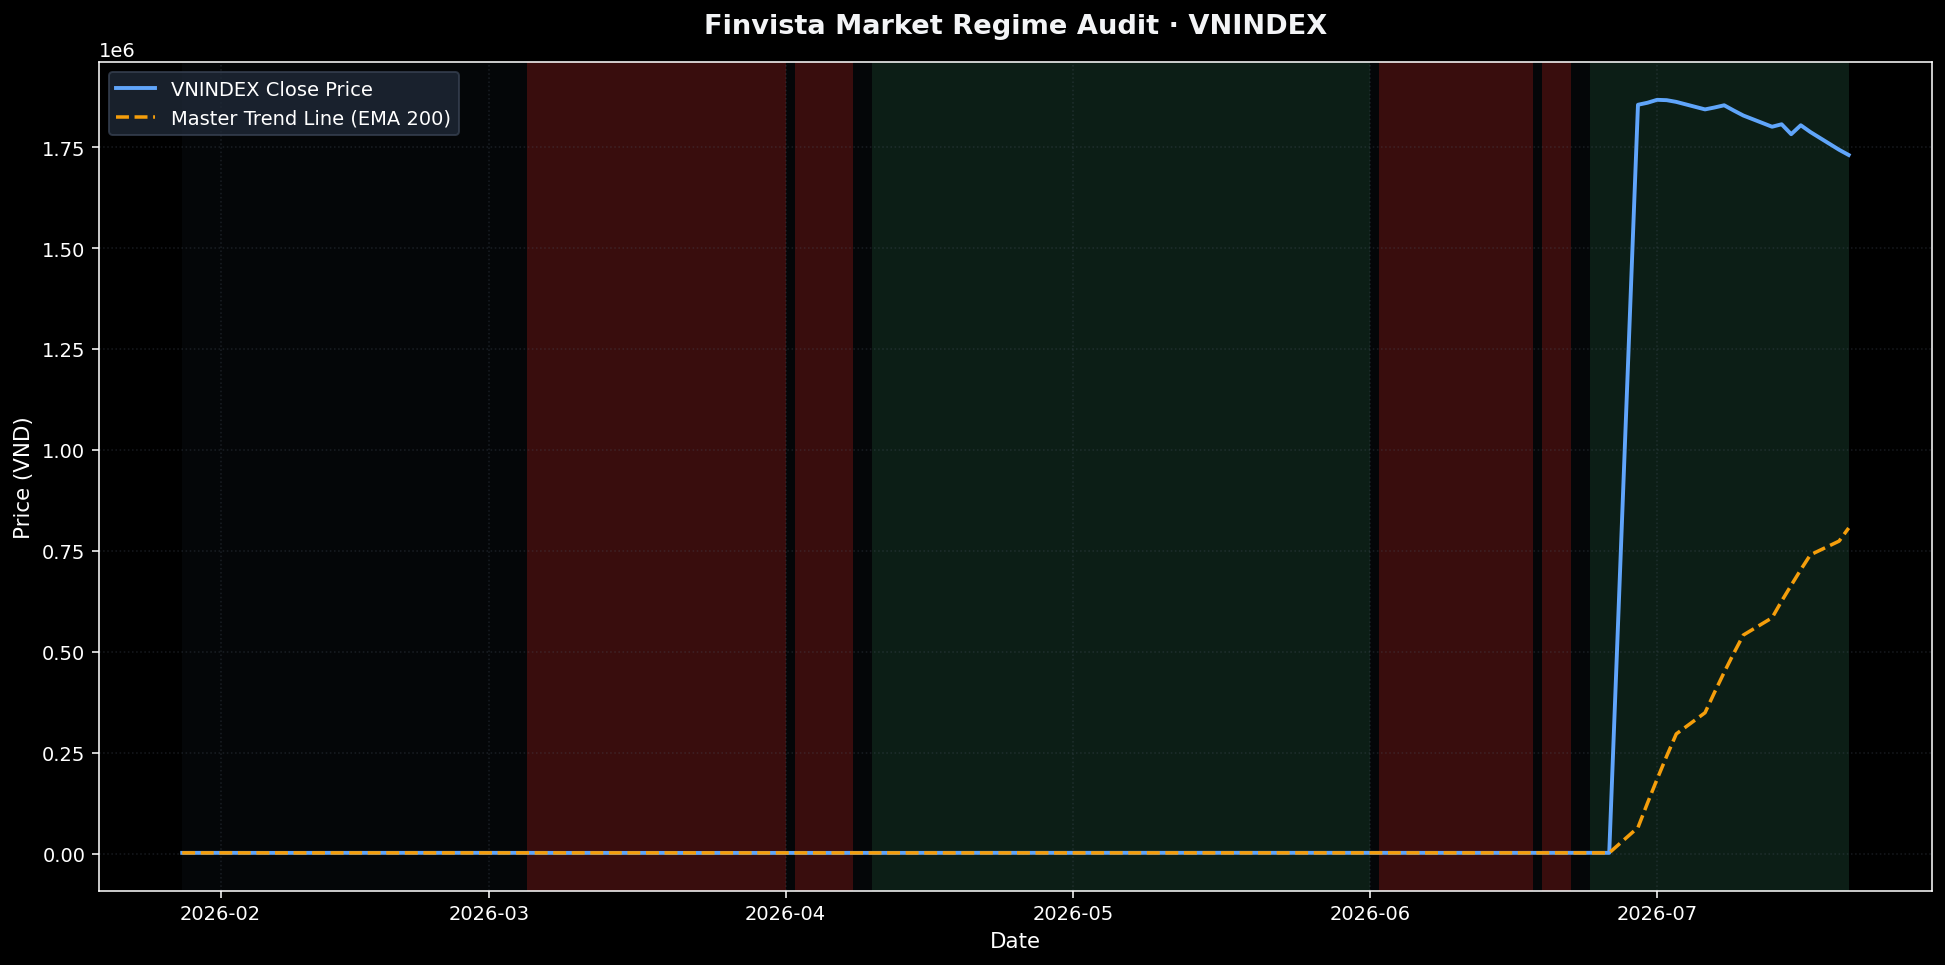

In [10]:
# Compute sliding regime history
closes = df['close'].values
dates = df['date'].values
ema200 = pd.Series(closes).ewm(span=min(200, len(closes)//2), adjust=False).mean().values

regimes = []
for i in range(len(df)):
    if i < 20:
        regimes.append("SIDEWAYS")
        continue
    sub_df = df.iloc[max(0, i-200):i+1]
    res = calculate_creed_regime_from_df(sub_df, trend_period=200)
    regimes.append(res.get("regime", "SIDEWAYS"))

# Render dark theme plot
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(14, 7), dpi=140)

for i in range(len(dates) - 1):
    r = regimes[i]
    color = '#1b4332' if r == 'BULLISH_VOL_EXPANSION' else ('#7f1d1d' if r == 'BEARISH_HIGH_VOL' else '#1f2937')
    alpha = 0.45 if r != 'SIDEWAYS' else 0.15
    ax.axvspan(dates[i], dates[i+1], color=color, alpha=alpha, linewidth=0)

ax.plot(dates, closes, label=f'{symbol} Close Price', color='#60a5fa', linewidth=2.0)
ax.plot(dates, ema200, label='Master Trend Line (EMA 200)', color='#f59e0b', linestyle='--', linewidth=1.8)

ax.set_title(f"Finvista Market Regime Audit · {symbol}", fontsize=14, fontweight='bold', pad=15, color='#f3f4f6')
ax.set_ylabel("Price (VND)", fontsize=11)
ax.set_xlabel("Date", fontsize=11)
ax.grid(True, linestyle=':', alpha=0.3, color='#4b5563')
ax.legend(loc='upper left', facecolor='#1f2937', edgecolor='#374151')

plt.tight_layout()
plt.show()

## ⚖️ Step 4: Regime-Adaptive Portfolio Weight Matrix
Adjust exposure and capital allocation dynamically based on the active regime.

In [11]:
allocation_matrix = {
    "BULLISH_VOL_EXPANSION": {"Equity_Weight": "100%", "Covered_Warrants": "12% max", "Stop_Loss": "5.0%", "Bias": "LONG_CW"},
    "BULLISH_VOL_CONTRACTION": {"Equity_Weight": "80%", "Covered_Warrants": "10% max", "Stop_Loss": "4.0%", "Bias": "ACCUMULATE"},
    "BEARISH_HIGH_VOL": {"Equity_Weight": "20%", "Covered_Warrants": "0% (SKIP)", "Stop_Loss": "2.5%", "Bias": "DEFENSIVE_CASH"},
    "SIDEWAYS": {"Equity_Weight": "50%", "Covered_Warrants": "5% max", "Stop_Loss": "3.5%", "Bias": "RANGE_TRADING"}
}

curr_regime = latest_regime.get("regime", "SIDEWAYS")
active_alloc = allocation_matrix.get(curr_regime, allocation_matrix["SIDEWAYS"])

print(f"🎯 CURRENT ACTIVE REGIME : {curr_regime}")
print(f"📌 RECOMMENDED BIAS      : {active_alloc['Bias']}")
print(f"📈 EQUITY EXPOSURE       : {active_alloc['Equity_Weight']}")
print(f"🎫 CW ALLOCATION LIMIT   : {active_alloc['Covered_Warrants']}")
print(f"🛡️ REGIME STOP LOSS      : {active_alloc['Stop_Loss']}")

🎯 CURRENT ACTIVE REGIME : BULLISH_VOL_EXPANSION
📌 RECOMMENDED BIAS      : LONG_CW
📈 EQUITY EXPOSURE       : 100%
🎫 CW ALLOCATION LIMIT   : 12% max
🛡️ REGIME STOP LOSS      : 5.0%
